/home/csgrads/shahr072/anaconda3/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/csgrads/shahr072/anaconda3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

AttributeError: 'UpSet' object has no attribute 'ax_dict'

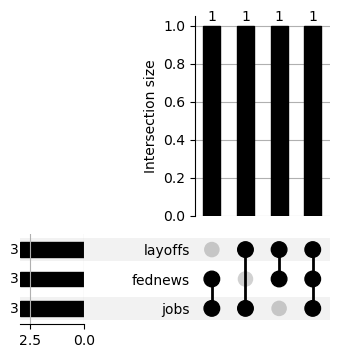

In [ ]:
# pip install upsetplot matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
## adding this as a host
# Intersections (pairwise + three-way) with your counts
memberships = [
    ("jobs", "layoffs"),           # 991
    ("jobs", "fednews"),           # 353
    ("layoffs", "fednews"),        # 82
    ("jobs", "fednews", "layoffs") # 19
]
counts = [991, 353, 82, 19]

# Build UpSet input
data = from_memberships(memberships, data=counts)
data.index.names = ["jobs", "fednews", "layoffs"]  # row order in the matrix

# Plot
fig = plt.figure(figsize=(9, 5))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="degree",          # pairwise before three-way
    sort_categories_by=None,   # keep category row order as set above
)
up.plot(fig=fig)

# Titles / labels
up.ax_dict["intersections"].set_title("Author Co-occurrence Across Subreddits")
up.ax_dict["intersections"].set_ylabel("Count")

plt.tight_layout()
plt.show()
# plt.savefig("figure3_upset.png", dpi=300, bbox_inches="tight")


In [3]:
# this is an example of loading and iterating over a single file

import zstandard
import os
import json
import sys
from datetime import datetime
import logging.handlers


log = logging.getLogger("bot")
log.setLevel(logging.DEBUG)
log.addHandler(logging.StreamHandler())


def read_and_decode(reader, chunk_size, max_window_size, previous_chunk=None, bytes_read=0):
	chunk = reader.read(chunk_size)
	bytes_read += chunk_size
	if previous_chunk is not None:
		chunk = previous_chunk + chunk
	try:
		return chunk.decode()
	except UnicodeDecodeError:
		if bytes_read > max_window_size:
			raise UnicodeError(f"Unable to decode frame after reading {bytes_read:,} bytes")
		log.info(f"Decoding error with {bytes_read:,} bytes, reading another chunk")
		return read_and_decode(reader, chunk_size, max_window_size, chunk, bytes_read)


def read_lines_zst(file_name):
	with open(file_name, 'rb') as file_handle:
		buffer = ''
		reader = zstandard.ZstdDecompressor(max_window_size=2**31).stream_reader(file_handle)
		while True:
			chunk = read_and_decode(reader, 2**27, (2**29) * 2)

			if not chunk:
				break
			lines = (buffer + chunk).split("\n")

			for line in lines[:-1]:
				yield line, file_handle.tell()

			buffer = lines[-1]

		reader.close()


if __name__ == "__main__":
	file_path = "Layoffs_submissions.zst"
	file_size = os.stat(file_path).st_size
	file_lines = 0
	file_bytes_processed = 0
	created = None
	field = "subreddit"
	value = "Layoffs"
	bad_lines = 0
	# try:
	for line, file_bytes_processed in read_lines_zst(file_path):
		try:
			obj = json.loads(line)
			created = datetime.utcfromtimestamp(int(obj['created_utc']))
			#temp = obj[field] == value
			if obj.get(field) == value:
				print(f"\n--- Sample Comment #{file_lines + 1} ---")
				print(f"Author: {obj.get('author', 'N/A')}")
				print(f"Created: {created}")
				print(f"title: {obj.get('title', 'N/A')}")
				print(f"selftext: {obj.get('selftext', 'N/A')}")
				print(f"num_comments: {obj.get('num_comments', 'N/A')}")
				#print(f"Full JSON: {json.dumps(obj, indent=2)}")
			
		except (KeyError, json.JSONDecodeError) as err:
			bad_lines += 1
		file_lines += 1
		if file_lines % 100000 == 0:
			log.info(f"{created.strftime('%Y-%m-%d %H:%M:%S')} : {file_lines:,} : {bad_lines:,} : {file_bytes_processed:,}:{(file_bytes_processed / file_size) * 100:.0f}%")

	# except Exception as err:
	# 	log.info(err)

	log.info(f"Complete : {file_lines:,} : {bad_lines:,}")


/tmp/ipykernel_2381073/3743476446.py:62: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  created = datetime.utcfromtimestamp(int(obj['created_utc']))



--- Sample Comment #1 ---
Author: distertastin
Created: 2011-08-19 22:27:28
title: Layoffs underway at Carlsbad-based Life Technologies - Carlsbad, CA
selftext: 
num_comments: 0

--- Sample Comment #2 ---
Author: distertastin
Created: 2011-08-19 22:26:42
title: Department of Mental Health lays off 582 statewide - Montgomery, AL
selftext: 
num_comments: 0

--- Sample Comment #3 ---
Author: distertastin
Created: 2011-08-19 22:25:56
title: DOE approves up to 1,100 additional layoffs at Hanford
selftext: 
num_comments: 0

--- Sample Comment #4 ---
Author: distertastin
Created: 2011-08-19 22:25:15
title: 700 Ohio home weatherization workers face layoffs as stimulus funds dry up
selftext: 
num_comments: 0

--- Sample Comment #5 ---
Author: distertastin
Created: 2011-08-19 22:23:53
title: I discovered this site and will be stealing from its daily links as a public service!
selftext: 
num_comments: 0

--- Sample Comment #6 ---
Author: distertastin
Created: 2011-08-19 22:20:23
title: Bank of A

Complete : 6,965 : 0
Complete : 6,965 : 0
Complete : 6,965 : 0


In [4]:
# this is an example of loading and iterating over a single file

import zstandard
import os
import json
import sys
from datetime import datetime
import logging.handlers


log = logging.getLogger("bot")
log.setLevel(logging.DEBUG)
log.addHandler(logging.StreamHandler())


def read_and_decode(reader, chunk_size, max_window_size, previous_chunk=None, bytes_read=0):
	chunk = reader.read(chunk_size)
	bytes_read += chunk_size
	if previous_chunk is not None:
		chunk = previous_chunk + chunk
	try:
		return chunk.decode()
	except UnicodeDecodeError:
		if bytes_read > max_window_size:
			raise UnicodeError(f"Unable to decode frame after reading {bytes_read:,} bytes")
		log.info(f"Decoding error with {bytes_read:,} bytes, reading another chunk")
		return read_and_decode(reader, chunk_size, max_window_size, chunk, bytes_read)


def read_lines_zst(file_name):
	with open(file_name, 'rb') as file_handle:
		buffer = ''
		reader = zstandard.ZstdDecompressor(max_window_size=2**31).stream_reader(file_handle)
		while True:
			chunk = read_and_decode(reader, 2**27, (2**29) * 2)

			if not chunk:
				break
			lines = (buffer + chunk).split("\n")

			for line in lines[:-1]:
				yield line, file_handle.tell()

			buffer = lines[-1]

		reader.close()


if __name__ == "__main__":
	file_path = "Layoffs_submissions.zst"
	output_file = "Layoffs_submissions_filtered.jsonl"
	file_size = os.stat(file_path).st_size
	file_lines = 0
	file_bytes_processed = 0
	created = None
	field = "subreddit"
	value = "Layoffs"
	bad_lines = 0
	posts_saved = 0
	
	# Open output file for writing
	with open(output_file, 'w', encoding='utf-8') as outfile:
		for line, file_bytes_processed in read_lines_zst(file_path):
			try:
				obj = json.loads(line)
				created = datetime.utcfromtimestamp(int(obj['created_utc']))
				
				if obj.get(field) == value:
					# Create filtered object with only the fields we want
					filtered_post = {
						"title": obj.get('title', 'N/A'),
						"author": obj.get('author', 'N/A'),
						"selftext": obj.get('selftext', 'N/A'),
						"created_utc": obj.get('created_utc', 'N/A'),
						"created_date": created.strftime('%Y-%m-%d %H:%M:%S'),  # Convert to normal date
						"num_comments": obj.get('num_comments', 'N/A')
					}
					
					# Write as JSON line to the output file
					json.dump(filtered_post, outfile)
					outfile.write('\n')
					posts_saved += 1
					
					# Print first few posts for verification
					if posts_saved <= 3:
						print(f"\n--- Sample Post #{posts_saved} ---")
						print(f"Author: {filtered_post['author']}")
						print(f"Created: {filtered_post['created_date']}")
						print(f"Title: {filtered_post['title'][:100]}...")  # First 100 chars
						print(f"Num Comments: {filtered_post['num_comments']}")
			
			except (KeyError, json.JSONDecodeError) as err:
				bad_lines += 1
			
			file_lines += 1
			if file_lines % 100000 == 0:
				log.info(f"{created.strftime('%Y-%m-%d %H:%M:%S')} : {file_lines:,} : {bad_lines:,} : {posts_saved:,} posts saved : {file_bytes_processed:,}:{(file_bytes_processed / file_size) * 100:.0f}%")

	log.info(f"Complete : {file_lines:,} lines processed : {bad_lines:,} bad lines : {posts_saved:,} posts saved to {output_file}")

/tmp/ipykernel_2381073/3304545746.py:66: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  created = datetime.utcfromtimestamp(int(obj['created_utc']))



--- Sample Post #1 ---
Author: distertastin
Created: 2011-08-19 22:27:28
Title: Layoffs underway at Carlsbad-based Life Technologies - Carlsbad, CA...
Num Comments: 0

--- Sample Post #2 ---
Author: distertastin
Created: 2011-08-19 22:26:42
Title: Department of Mental Health lays off 582 statewide - Montgomery, AL...
Num Comments: 0

--- Sample Post #3 ---
Author: distertastin
Created: 2011-08-19 22:25:56
Title: DOE approves up to 1,100 additional layoffs at Hanford...
Num Comments: 0


Complete : 6,965 lines processed : 0 bad lines : 6,965 posts saved to Layoffs_submissions_filtered.jsonl
Complete : 6,965 lines processed : 0 bad lines : 6,965 posts saved to Layoffs_submissions_filtered.jsonl
Complete : 6,965 lines processed : 0 bad lines : 6,965 posts saved to Layoffs_submissions_filtered.jsonl
Complete : 6,965 lines processed : 0 bad lines : 6,965 posts saved to Layoffs_submissions_filtered.jsonl


In [4]:
import json
from datetime import datetime
import os

def count_posts_by_date_range(input_file, start_date, end_date, output_file=None):
    """
    Count posts between start_date and end_date, and optionally save them to a file
    
    Args:
        input_file: Path to JSONL file
        start_date: Start date as string 'YYYY-MM-DD'
        end_date: End date as string 'YYYY-MM-DD'
        output_file: Optional path to save filtered posts
    
    Returns:
        tuple: (count, total_posts, min_date, max_date)
    """
    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')
    
    count_in_range = 0
    total_posts = 0
    min_date = None
    max_date = None
    
    # If output file is specified, open it for writing
    output_handle = None
    if output_file:
        output_handle = open(output_file, 'w', encoding='utf-8')
    
    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():  # Skip empty lines
                try:
                    post = json.loads(line)
                    total_posts += 1
                    
                    # Trim created_date to just YYYY-MM-DD
                    if 'created_date' in post:
                        full_date = post['created_date']
                        date_only = full_date.split()[0]  # Get just the date part
                        post['created_date'] = date_only
                        
                        # Update min and max dates
                        current_date = datetime.strptime(date_only, '%Y-%m-%d')
                        if min_date is None or current_date < min_date:
                            min_date = current_date
                        if max_date is None or current_date > max_date:
                            max_date = current_date
                        
                        # Check if in target date range
                        if start_dt <= current_date <= end_dt:
                            count_in_range += 1
                            if output_handle:
                                json.dump(post, output_handle)
                                output_handle.write('\n')
                    
                except json.JSONDecodeError as e:
                    print(f"Error parsing line: {e}")
                    continue
    
    if output_handle:
        output_handle.close()
    
    return count_in_range, total_posts, min_date, max_date

def main():
    input_file = "Layoffs_submissions_filtered.jsonl"
    timeframe_output_file = "Layoffs_submissions_2022_2025.jsonl"
    
    # Define your date range
    start_date = "2022-01-01"
    end_date = "2025-04-30"
    
    print("Analyzing posts...")
    
    # Count posts in date range and get statistics
    count_in_range, total_posts, min_date, max_date = count_posts_by_date_range(
        input_file, start_date, end_date, timeframe_output_file
    )
    
    print("\n=== ANALYSIS RESULTS ===")
    print(f"Total posts: {total_posts:,}")
    print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
    print(f"Posts between {start_date} and {end_date}: {count_in_range:,}")
    print(f"Posts saved to: {timeframe_output_file}")
    
    # Example of using the function with different dates
    print("\n=== OTHER DATE RANGES ===")
    
    # Count posts in 2020-2021
    count_2011_2021, _, _, _ = count_posts_by_date_range(
        input_file, "2011-08-19", "2022-11-30"
    )
    print(f"Posts in 2011- Nov 2022: {count_2011_2021:,}")

    count_2022_2021, _, _, _ = count_posts_by_date_range(
        input_file, "2022-01-01", "2022-11-30"
    )
    print(f"Posts in 2011- Nov 2022: {count_2022_2021:,}")
    
    # Count posts in 2023 only
    count_2023, _, _, _ = count_posts_by_date_range(
        input_file, "2023-01-01", "2023-12-31"
    )
    print(f"Posts in 2023: {count_2023:,}")
    
    # You can easily test other date ranges by calling the function:
    # count, total, min_d, max_d = count_posts_by_date_range(input_file, "2019-01-01", "2019-12-31")

if __name__ == "__main__":
    main()

Analyzing posts...

=== ANALYSIS RESULTS ===
Total posts: 6,965
Date range: 2011-08-19 to 2024-12-31
Posts between 2022-01-01 and 2025-04-30: 6,674
Posts saved to: Layoffs_submissions_2022_2025.jsonl

=== OTHER DATE RANGES ===
Posts in 2011- Nov 2022: 301
Posts in 2011- Nov 2022: 10
Posts in 2023: 528
